In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set(style="whitegrid")

In [9]:
df = pd.read_csv("dataset.csv")

print("Shape:", df.shape)
df.head()

Shape: (8128, 13)


,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0


In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           8128 non-null   str    
 1   year           8128 non-null   int64  
 2   selling_price  8128 non-null   int64  
 3   km_driven      8128 non-null   int64  
 4   fuel           8128 non-null   str    
 5   seller_type    8128 non-null   str    
 6   transmission   8128 non-null   str    
 7   owner          8128 non-null   str    
 8   mileage        7907 non-null   str    
 9   engine         7907 non-null   str    
 10  max_power      7913 non-null   str    
 11  torque         7906 non-null   str    
 12  seats          7907 non-null   float64
dtypes: float64(1), int64(3), str(9)
memory usage: 825.6 KB


In [11]:
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100

pd.DataFrame({
    "Missing": missing,
    "Percent": missing_percent
}).sort_values(by="Percent", ascending=False)

,Missing,Percent
torque,222,2.731299
seats,221,2.718996
engine,221,2.718996
mileage,221,2.718996
max_power,215,2.645177
fuel,0,0.000000
km_driven,0,0.000000
selling_price,0,0.000000
year,0,0.000000
name,0,0.000000


In [13]:
df.duplicated().sum()
df.drop_duplicates(inplace=True)

In [16]:

def clean_numeric(column):
    return pd.to_numeric(
        column.astype(str).str.extract(r'(\d+\.?\d*)')[0],
        errors='coerce'
    )

# Apply cleaning
df['mileage'] = clean_numeric(df['mileage'])
df['engine'] = clean_numeric(df['engine'])
df['max_power'] = clean_numeric(df['max_power'])

In [17]:


df['torque'] = pd.to_numeric(
    df['torque'].astype(str).str.extract(r'(\d+\.?\d*)')[0],
    errors='coerce'
)

In [19]:
#Fill missing values properly
df['mileage'] = df['mileage'].fillna(df['mileage'].median())
df['engine'] = df['engine'].fillna(df['engine'].median())
df['max_power'] = df['max_power'].fillna(df['max_power'].median())
df['torque'] = df['torque'].fillna(df['torque'].median())
df['seats'] = df['seats'].fillna(df['seats'].mode()[0])

In [20]:
# Brand extraction
df['brand'] = df['name'].astype(str).apply(lambda x: x.split()[0])

# Car age (dynamic)
current_year = pd.Timestamp.now().year
df['car_age'] = current_year - df['year']

In [21]:
df.info()

df[['mileage','engine','max_power','torque','seats']].describe()

<class 'pandas.DataFrame'>
Index: 6926 entries, 0 to 8125
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           6926 non-null   str    
 1   year           6926 non-null   int64  
 2   selling_price  6926 non-null   int64  
 3   km_driven      6926 non-null   int64  
 4   fuel           6926 non-null   str    
 5   seller_type    6926 non-null   str    
 6   transmission   6926 non-null   str    
 7   owner          6926 non-null   str    
 8   mileage        6926 non-null   float64
 9   engine         6926 non-null   float64
 10  max_power      6926 non-null   float64
 11  torque         6926 non-null   float64
 12  seats          6926 non-null   float64
 13  brand          6926 non-null   str    
 14  car_age        6926 non-null   int64  
dtypes: float64(5), int64(4), str(6)
memory usage: 865.8 KB


,mileage,engine,max_power,torque,seats
count,6926.000000,6926.000000,6926.000000,6926.000000,6926.000000
mean,19.464550,1425.398787,87.551527,160.406591,5.421600
std,3.987878,487.026967,31.311523,90.272744,0.972171
min,0.000000,624.000000,0.000000,4.800000,2.000000
25%,16.950000,1197.000000,68.000000,99.000000,5.000000
50%,19.440000,1248.000000,81.830000,146.000000,5.000000
75%,22.320000,1498.000000,99.000000,200.000000,5.000000
max,42.000000,3604.000000,400.000000,789.000000,14.000000


In [22]:
num_cols = [
    'selling_price','km_driven','mileage',
    'engine','max_power','torque','car_age'
]

df[num_cols].describe()

,selling_price,km_driven,mileage,engine,max_power,torque,car_age
count,6.926000e+03,6.926000e+03,6926.000000,6926.000000,6926.000000,6926.000000,6926.000000
mean,5.172707e+05,7.399568e+04,19.464550,1425.398787,87.551527,160.406591,12.579700
std,5.197670e+05,5.835810e+04,3.987878,487.026967,31.311523,90.272744,4.078286
min,2.999900e+04,1.000000e+00,0.000000,624.000000,0.000000,4.800000,6.000000
25%,2.500000e+05,4.000000e+04,16.950000,1197.000000,68.000000,99.000000,9.000000
50%,4.000000e+05,7.000000e+04,19.440000,1248.000000,81.830000,146.000000,12.000000
75%,6.335000e+05,1.000000e+05,22.320000,1498.000000,99.000000,200.000000,15.000000
max,1.000000e+07,2.360457e+06,42.000000,3604.000000,400.000000,789.000000,43.000000


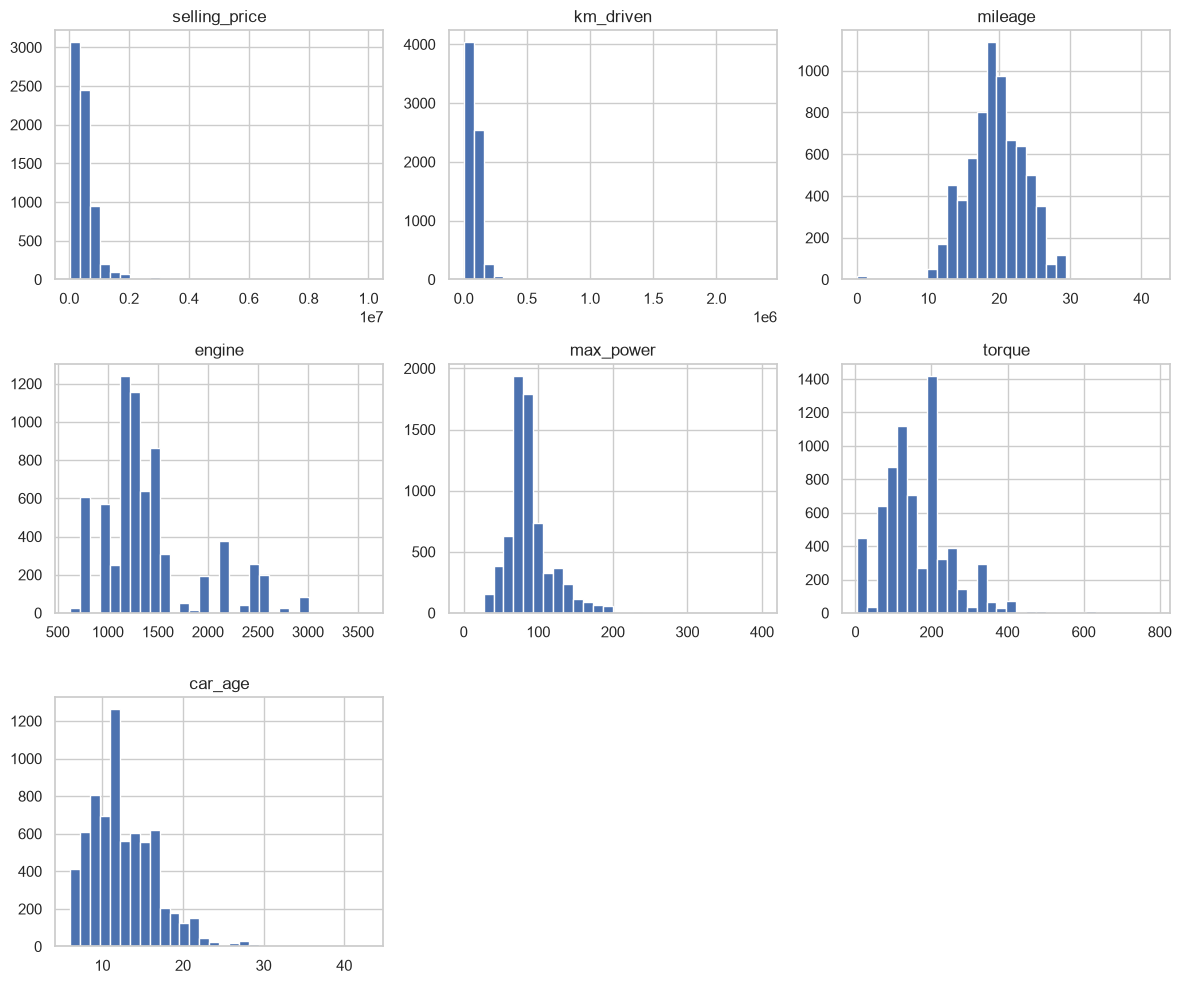

In [23]:
df[num_cols].hist(figsize=(12,10), bins=30)
plt.tight_layout()
plt.show()

In [24]:
cat_cols = ['fuel','seller_type','transmission','owner','brand']

for col in cat_cols:
    print(f"\n{col}:")
    print(df[col].value_counts())


fuel:
fuel
Diesel    3755
Petrol    3077
CNG         56
LPG         38
Name: count, dtype: int64

seller_type:
seller_type
Individual          6218
Dealer               681
Trustmark Dealer      27
Name: count, dtype: int64

transmission:
transmission
Manual       6342
Automatic     584
Name: count, dtype: int64

owner:
owner
First Owner             4242
Second Owner            1974
Third Owner              536
Fourth & Above Owner     169
Test Drive Car             5
Name: count, dtype: int64

brand:
brand
Maruti           2165
Hyundai          1267
Mahindra          723
Tata              647
Honda             362
Ford              361
Toyota            357
Chevrolet         216
Renault           206
Volkswagen        174
Nissan             73
Skoda              70
Datsun             57
BMW                47
Mercedes-Benz      46
Fiat               44
Audi               33
Jeep               22
Mitsubishi         11
Volvo               9
Jaguar              8
Force               4
Am

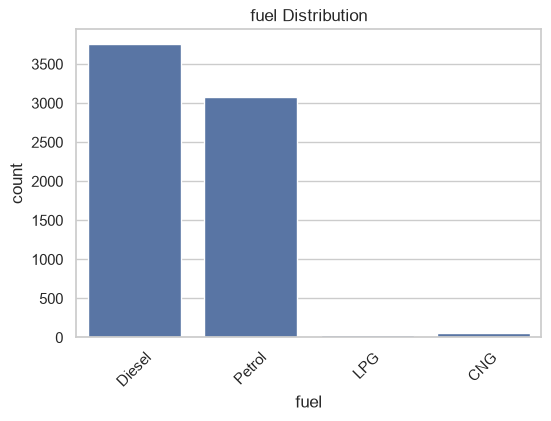

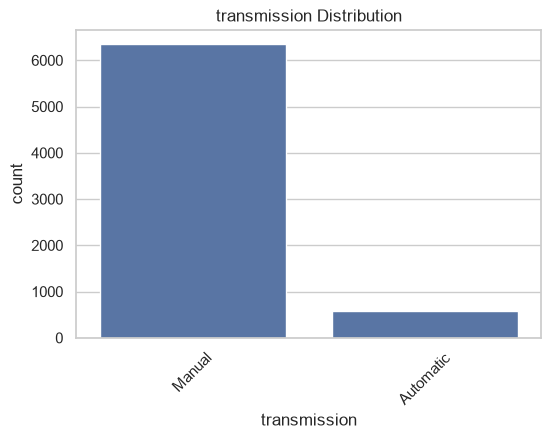

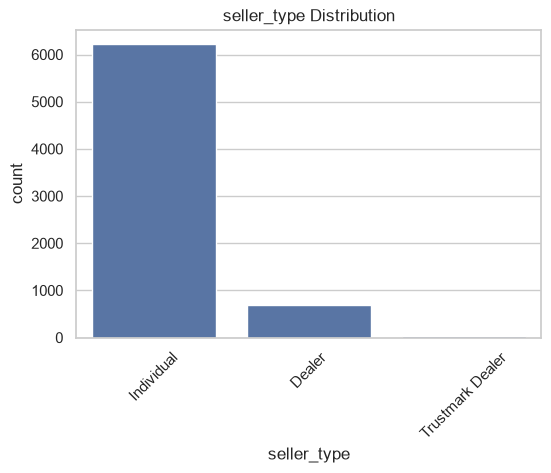

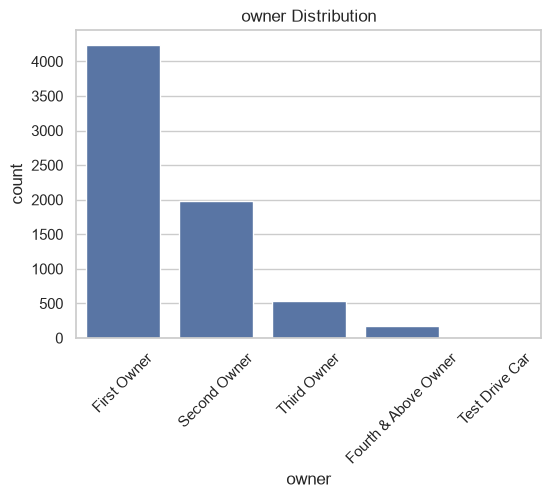

In [25]:
for col in ['fuel','transmission','seller_type','owner']:
    plt.figure(figsize=(6,4))
    sns.countplot(data=df, x=col)
    plt.xticks(rotation=45)
    plt.title(f"{col} Distribution")
    plt.show()

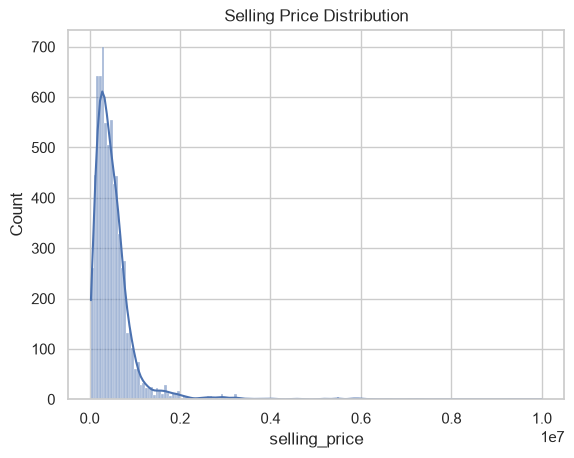

In [26]:
sns.histplot(df['selling_price'], kde=True)
plt.title("Selling Price Distribution")
plt.show()

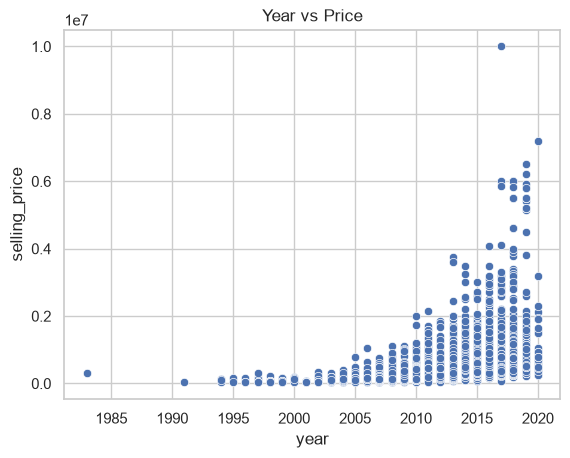

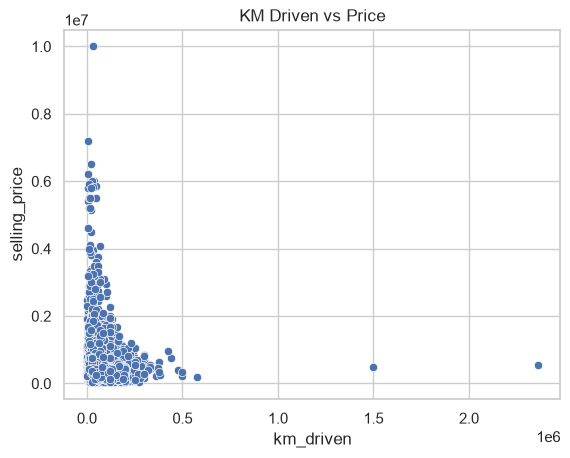

In [27]:
sns.scatterplot(data=df, x='year', y='selling_price')
plt.title("Year vs Price")
plt.show()

sns.scatterplot(data=df, x='km_driven', y='selling_price')
plt.title("KM Driven vs Price")
plt.show()

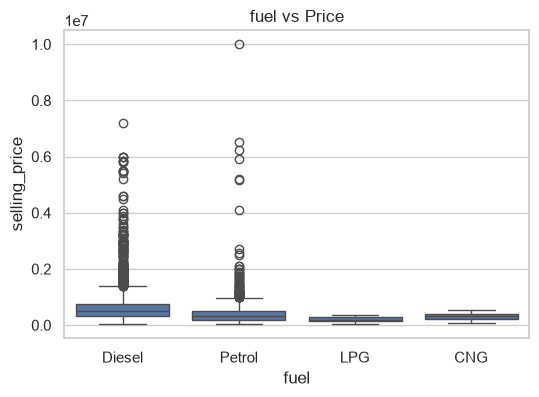

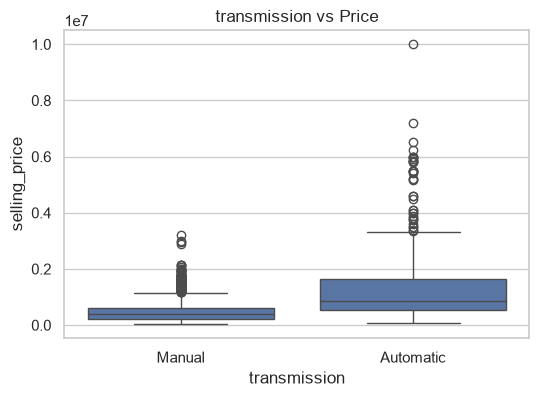

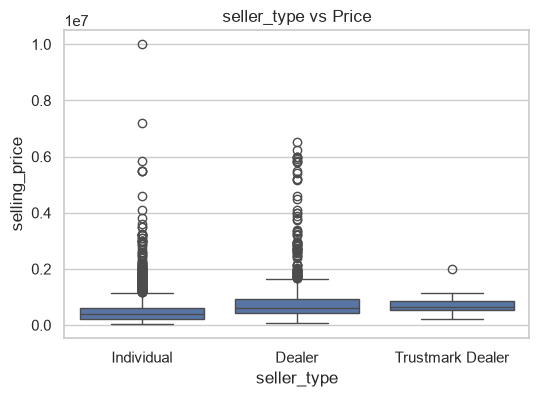

In [28]:
for col in ['fuel','transmission','seller_type']:
    plt.figure(figsize=(6,4))
    sns.boxplot(data=df, x=col, y='selling_price')
    plt.title(f"{col} vs Price")
    plt.show()

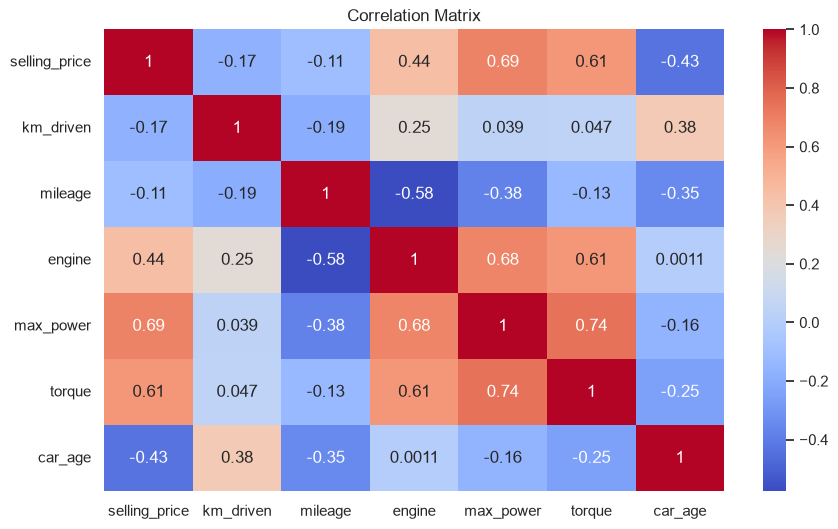

In [29]:
plt.figure(figsize=(10,6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

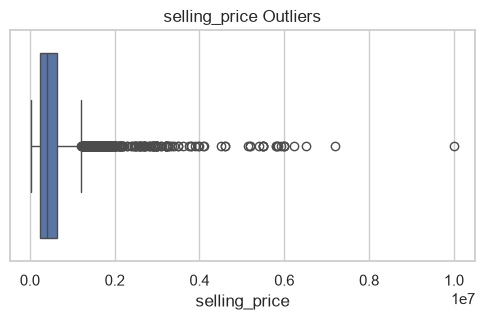

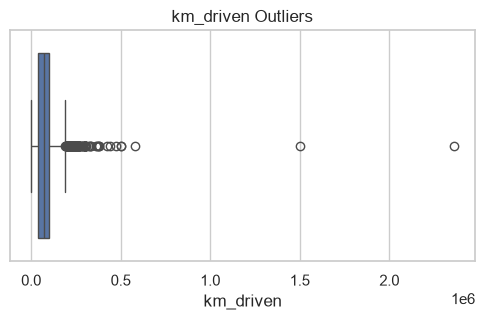

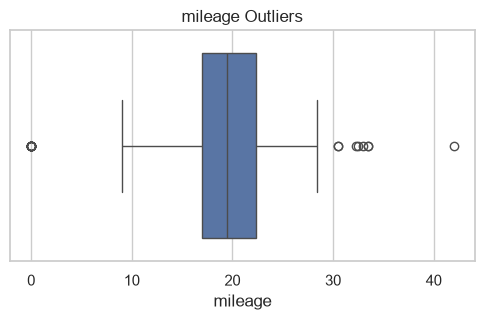

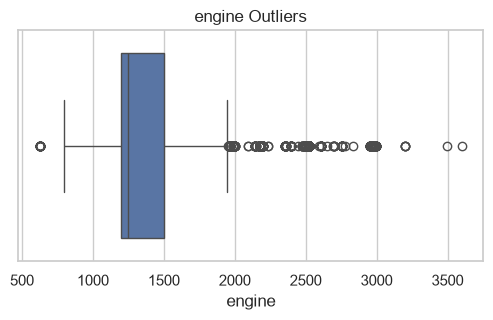

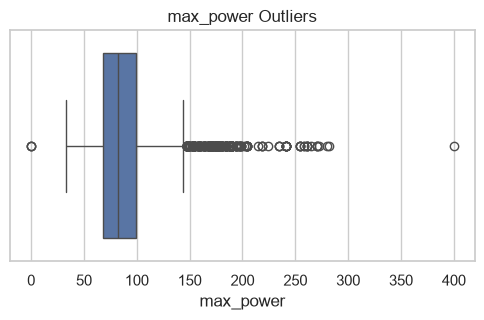

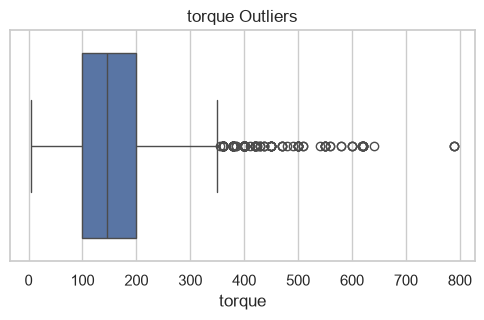

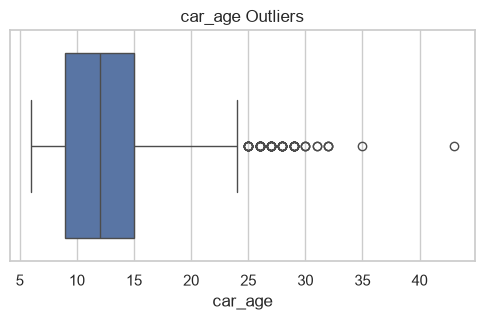

In [30]:
for col in num_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(f"{col} Outliers")
    plt.show()

In [63]:
Q1 = df[num_cols].quantile(0.25)
Q3 = df[num_cols].quantile(0.75)
IQR = Q3 - Q1

df_clean = df[
    ~((df[num_cols] < (Q1 - 1.5 * IQR)) |
      (df[num_cols] > (Q3 + 1.5 * IQR))).any(axis=1)
]

print("Before:", df.shape)
print("After:", df_clean.shape)

Before: (6926, 15)
After: (5494, 15)


In [33]:
df_clean.to_csv("EDADATA.csv", index=False)

In [64]:
df_model = df_clean.copy()
df_model.drop(['name'], axis=1, inplace=True)
df_model = pd.get_dummies(df_model, drop_first=True)

In [65]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

In [66]:
from sklearn.model_selection import train_test_split

X = df_model.drop('selling_price', axis=1)
y = df_model['selling_price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [85]:
lr = LinearRegression()
lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](32,)","[ 16681.19, -0.8 , -5729.83,...,-57800.11, 65340.7 ,-44484.43]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](32,)","['year','km_driven','mileage',...,'brand_Tata','brand_Toyota', 'brand_Volkswagen']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-3.325e+07
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,32
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,29


In [92]:
y_pred = lr.predict(X_test)

In [87]:
print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))

R2 Score: 0.7902291672047819
MAE: 83732.48586143224


In [88]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

pipeline = Pipeline([
    ("scaler", StandardScaler()),   # preprocessing
    ("model", LinearRegression())   # model
])

In [83]:
import pickle

pickle.dump(pipeline, open("linear_pipeline.pkl", "wb"))

In [84]:
pipeline = pickle.load(open("linear_pipeline.pkl", "rb"))

In [90]:
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](32,)","['year','km_driven','mileage',...,'brand_Tata','brand_Toyota', 'brand_Volkswagen']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,32
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
Name,Type,Value


In [91]:
pipeline.predict(X_test)

array([ 83312.42313342, 164380.78900236, 583275.15061935, ...,
       489369.06916788, 438238.30446215, 265545.72987264], shape=(1099,))

In [93]:
predictions = pipeline.predict(X_test)

print(predictions[:5])
print(y_test.iloc[:5].values)

[ 83312.42313342 164380.78900236 583275.15061935 669374.85731613
 666728.05874297]
[125000 130000 625000 700000 695000]


In [94]:
from sklearn.metrics import r2_score, mean_absolute_error

print("R2:", r2_score(y_test, predictions))
print("MAE:", mean_absolute_error(y_test, predictions))

R2: 0.7901030024339704
MAE: 83745.67564160422


In [95]:
import pandas as pd

result = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": predictions
})

result.head(10)

,Actual,Predicted
0,125000,83312.423133
1,130000,164380.789002
2,625000,583275.150619
3,700000,669374.857316
4,695000,666728.058743
5,300000,95465.089196
6,400000,412960.315637
7,145000,168237.410792
8,280000,343939.524151
9,650000,586027.728917


In [96]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

In [97]:
rf = RandomForestRegressor(
    n_estimators=300,       # more trees → better performance
    max_depth=20,           # prevents overfitting
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

In [98]:
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max

In [99]:
y_pred_rf = rf.predict(X_test)

In [100]:
print("Random Forest R2:", r2_score(y_test, y_pred_rf))
print("Random Forest MAE:", mean_absolute_error(y_test, y_pred_rf))

Random Forest R2: 0.8942123738062802
Random Forest MAE: 55305.28643797456


In [101]:
print("Linear R2:", r2_score(y_test, y_pred))
print("Random Forest R2:", r2_score(y_test, y_pred_rf))

Linear R2: 0.7902291672047819
Random Forest R2: 0.8942123738062802


In [102]:
rf_results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted_RF": y_pred_rf
})

rf_results.head(10)

,Actual,Predicted_RF
0,125000,111723.374231
1,130000,191310.604089
2,625000,572361.458199
3,700000,649985.886397
4,695000,747819.416288
5,300000,212979.583402
6,400000,366577.065064
7,145000,153481.414175
8,280000,267920.113598
9,650000,591550.471275


In [103]:
importance = pd.Series(rf.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=False)

print(importance.head(10))

year                  0.293011
car_age               0.273244
max_power             0.266137
torque                0.057510
km_driven             0.027455
mileage               0.026127
engine                0.018170
brand_Tata            0.009896
brand_Maruti          0.003254
owner_Second Owner    0.003232
dtype: float64


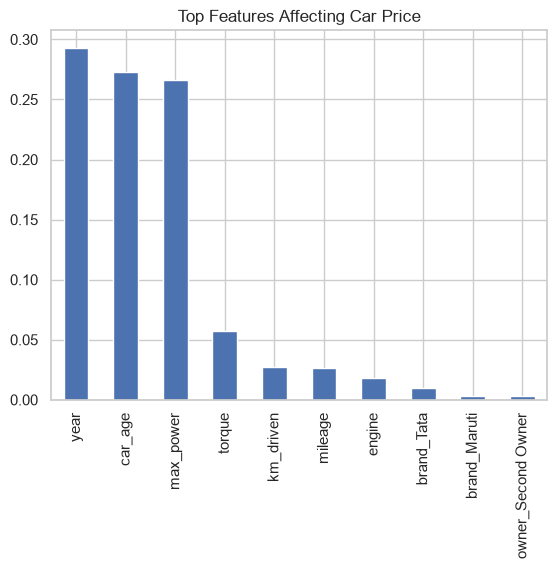

In [104]:
importance.head(10).plot(kind='bar')
plt.title("Top Features Affecting Car Price")
plt.show()

In [105]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor

rf_pipeline = Pipeline([
    ("model", RandomForestRegressor(
        n_estimators=300,
        max_depth=20,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    ))
])

In [106]:
rf_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](32,)","['year','km_driven','mileage',...,'brand_Tata','brand_Toyota', 'brand_Volkswagen']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,32
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2


In [107]:
y_pred_rf = rf_pipeline.predict(X_test)

from sklearn.metrics import r2_score
print("RF R2:", r2_score(y_test, y_pred_rf))

RF R2: 0.8942123738062802


In [108]:
print("R2 Score:", r2_score(y_test, y_pred_rf))
print("MAE:", mean_absolute_error(y_test, y_pred_rf))

R2 Score: 0.8942123738062802
MAE: 55305.28643797456


In [109]:
import pickle

pickle.dump(rf_pipeline, open("rf_pipeline.pkl", "wb"))

In [110]:
rf_pipeline = pickle.load(open("rf_pipeline.pkl", "rb"))

In [111]:
rf_pipeline.predict(X_test[:5])

array([111723.37423148, 191310.60408883, 572361.45819865, 649985.88639671,
       747819.41628812])